In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

In [6]:
df = pd.read_csv(
    "dhaka_smart_waste_10M_ultra.csv",
    nrows=100000
)

print(df.shape)
print(df.columns.tolist())

df.head()

(100000, 23)
['bin_id', 'city', 'area_type', 'neighborhood', 'date', 'time_slot', 'event', 'bin_capacity', 'fill_level', 'predicted_fill_level', 'overflow_kg', 'needs_collection', 'waste_type', 'latitude', 'longitude', 'weather', 'temperature', 'humidity', 'placement', 'nearby_business_type', 'population_density', 'time_factor', 'battery_level']


,bin_id,city,area_type,neighborhood,date,time_slot,event,bin_capacity,fill_level,predicted_fill_level,...,latitude,longitude,weather,temperature,humidity,placement,nearby_business_type,population_density,time_factor,battery_level
0,DHK-OF-00000,Dhaka,Office,Motijheel,2025-01-01,Night,Normal,50,1.93,9.05,...,23.726239,90.420311,Sunny,30.8,61.8,Roadside,Market,Low,0,100.0
1,DHK-RE-00001,Dhaka,Residential,Gulshan/Banani,2025-01-01,Night,Normal,100,5.55,11.83,...,23.784922,90.413517,Sunny,30.8,61.8,Office,Restaurant,Medium,0,100.0
2,DHK-RE-00002,Dhaka,Residential,Mirpur,2025-01-01,Night,Normal,100,5.76,11.34,...,23.828303,90.354015,Sunny,30.8,61.8,School,Garments,Medium,0,100.0
3,DHK-SL-00003,Dhaka,Slum,Gulshan/Banani,2025-01-01,Night,Normal,100,1.44,7.23,...,23.798940,90.407578,Sunny,30.8,61.8,Roadside,Office,High,0,100.0
4,DHK-RE-00004,Dhaka,Residential,Old Dhaka,2025-01-01,Night,Normal,50,8.94,13.16,...,23.702625,90.406896,Sunny,30.8,61.8,Indoor,Garments,Low,0,100.0


In [7]:
zone_map = {
    "Dhanmondi":"North",
    "Old Dhaka":"South",
    "Gulshan/Banani":"East",
    "Mirpur":"West",
    "Motijheel":"Central"
}

df["Zone"] = df["neighborhood"].map(zone_map)

df[["neighborhood","Zone"]].drop_duplicates()

,neighborhood,Zone
0,Motijheel,Central
1,Gulshan/Banani,East
2,Mirpur,West
4,Old Dhaka,South
6,Dhanmondi,North


In [8]:
np.random.seed(42)

composition = {
    "Residential":[70,12,10,2],
    "Office":[45,15,25,2],
    "Commercial":[50,25,15,3],
    "Industrial":[40,15,10,10],
    "Slum":[75,10,8,1]
}

organic = []
plastic = []
paper = []
metal = []

for area in df["area_type"]:

    o,p,pa,m = composition.get(
        area,
        [60,15,12,2]
    )

    organic.append(np.random.normal(o,5))
    plastic.append(np.random.normal(p,2))
    paper.append(np.random.normal(pa,2))
    metal.append(np.random.normal(m,1))

df["organic_pct"] = organic
df["plastic_pct"] = plastic
df["paper_pct"] = paper
df["metal_pct"] = metal

total = (
    df["organic_pct"]
    + df["plastic_pct"]
    + df["paper_pct"]
    + df["metal_pct"]
)

df["organic_pct"] = df["organic_pct"]/total*100
df["plastic_pct"] = df["plastic_pct"]/total*100
df["paper_pct"] = df["paper_pct"]/total*100
df["metal_pct"] = df["metal_pct"]/total*100

In [9]:
density_map = {
    "Low":33,
    "Medium":66,
    "High":100
}

df["population_score"] = (
    df["population_density"]
    .map(density_map)
)

In [10]:
area_map = {
    "Residential":60,
    "Office":80,
    "Commercial":100,
    "Industrial":70,
    "Slum":90
}

df["area_score"] = (
    df["area_type"]
    .map(area_map)
)

df["area_score"] = (
    df["area_score"]
    .fillna(70)
)

In [11]:
scaler = MinMaxScaler()

df[
    [
        "fill_level",
        "predicted_fill_level"
    ]
] = (
    scaler.fit_transform(
        df[
            [
                "fill_level",
                "predicted_fill_level"
            ]
        ]
    ) * 100
)

In [13]:
df["BSI"] = (
    0.7*df["fill_level"]
    +
    0.3*df["predicted_fill_level"]
)

In [14]:
df["RVI"] = (
    df["plastic_pct"]*0.8
    +
    df["paper_pct"]*0.6
    +
    df["metal_pct"]*1.0
    +
    df["organic_pct"]*0.3
)

In [15]:
df["HRI"] = (
    df["organic_pct"]*1.0
    +
    df["plastic_pct"]*0.6
    +
    df["paper_pct"]*0.3
    +
    df["metal_pct"]*0.2
)

In [16]:
df["ZPI"] = (
    0.6*df["population_score"]
    +
    0.4*df["area_score"]
)

In [17]:
df["DPS"] = (
    0.30*df["BSI"]
    +
    0.20*df["RVI"]
    +
    0.25*df["HRI"]
    +
    0.25*df["ZPI"]
)

In [18]:
def priority(score):

    if score >= 80:
        return "Critical"

    elif score >= 60:
        return "High"

    elif score >= 40:
        return "Medium"

    else:
        return "Low"

df["Priority"] = (
    df["DPS"]
    .apply(priority)
)

In [19]:
zone_summary = (
    df.groupby("Zone")
      .agg(
          Total_Bins=("bin_id","count"),
          Avg_DPS=("DPS","mean"),
          Max_DPS=("DPS","max")
      )
      .round(2)
)

zone_summary

,Total_Bins,Avg_DPS,Max_DPS
Zone,,,
Central,19240,54.13,83.21
East,20460,54.13,80.92
North,19940,53.65,81.31
South,19440,58.43,83.15
West,20920,56.65,83.83


In [20]:
neighborhood_summary = (
    df.groupby("neighborhood")
      .agg(
          Total_Bins=("bin_id","count"),
          Avg_DPS=("DPS","mean"),
          Max_DPS=("DPS","max")
      )
      .round(2)
      .sort_values(
          "Avg_DPS",
          ascending=False
      )
)

neighborhood_summary

,Total_Bins,Avg_DPS,Max_DPS
neighborhood,,,
Old Dhaka,19440,58.43,83.15
Mirpur,20920,56.65,83.83
Gulshan/Banani,20460,54.13,80.92
Motijheel,19240,54.13,83.21
Dhanmondi,19940,53.65,81.31


In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Distribution of Dispatch Priority Score (DPS)')

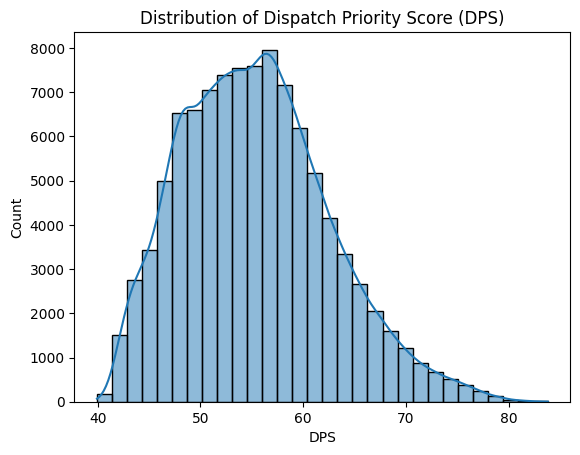

In [22]:
sns.histplot(
    df["DPS"],
    bins=30,
    kde=True
)

plt.title("Distribution of Dispatch Priority Score (DPS)")

In [17]:
priority_counts = (
    df["Priority"]
    .value_counts()
)

print(priority_counts)

Priority
Medium      75250
High        24699
Critical       50
Low             1
Name: count, dtype: int64


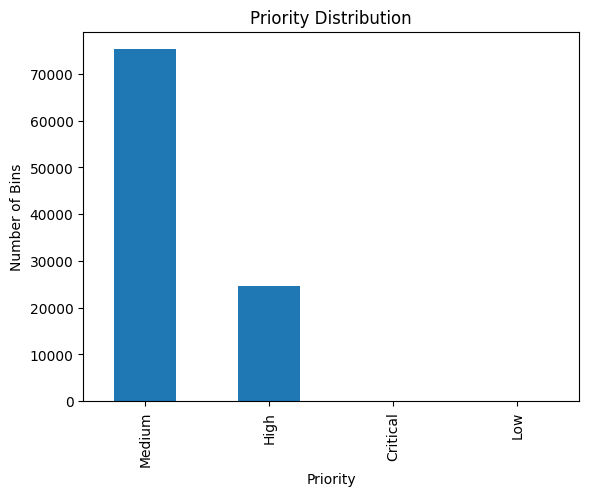

In [19]:
priority_counts.plot(
    kind="bar"
)

plt.title(
    "Priority Distribution"
)

plt.ylabel(
    "Number of Bins"
)

plt.show()

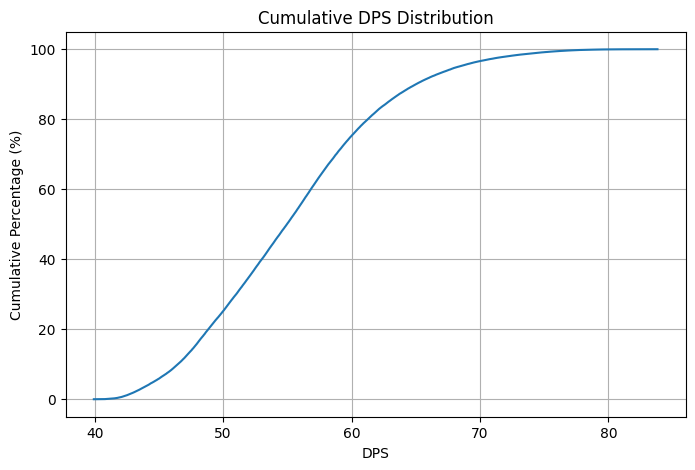

In [28]:
sorted_dps = np.sort(df["DPS"])

cum_percent = (
    np.arange(1, len(sorted_dps)+1)
    /
    len(sorted_dps)
) * 100

plt.figure(figsize=(8,5))

plt.plot(
    sorted_dps,
    cum_percent
)

plt.xlabel("DPS")
plt.ylabel("Cumulative Percentage (%)")

plt.title("Cumulative DPS Distribution")

plt.grid()

plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_8096\1290803235.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hri_avg = df.groupby(hri_bins)["DPS"].mean()


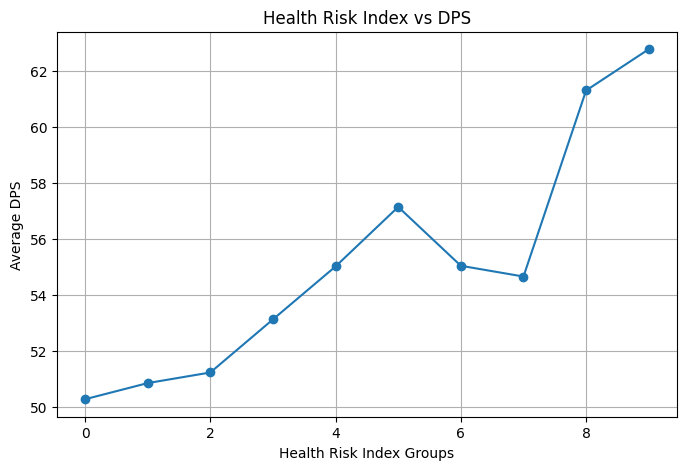

In [25]:
hri_bins = pd.cut(df["HRI"], bins=10)

hri_avg = df.groupby(hri_bins)["DPS"].mean()

plt.figure(figsize=(8,5))

plt.plot(
    range(len(hri_avg)),
    hri_avg.values,
    marker="o"
)

plt.title("Health Risk Index vs DPS")
plt.xlabel("Health Risk Index Groups")
plt.ylabel("Average DPS")

plt.grid(True)
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_8096\3002109615.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rvi_avg = df.groupby(rvi_bins)["DPS"].mean()


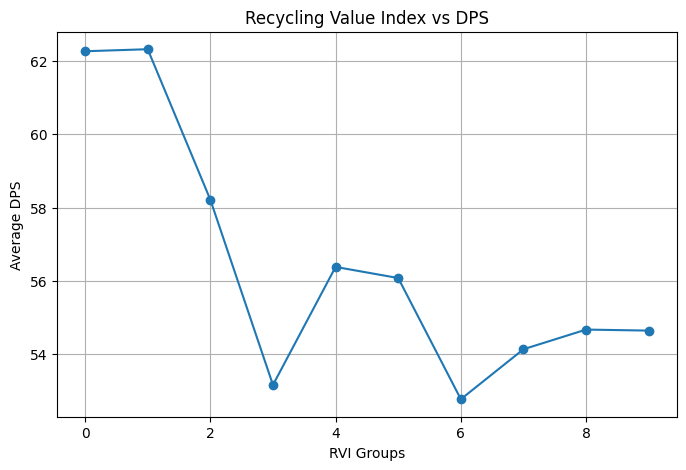

In [27]:
rvi_bins = pd.cut(df["RVI"], bins=10)

rvi_avg = df.groupby(rvi_bins)["DPS"].mean()

plt.figure(figsize=(8,5))

plt.plot(
    range(len(rvi_avg)),
    rvi_avg.values,
    marker="o"
)

plt.title("Recycling Value Index vs DPS")
plt.xlabel("RVI Groups")
plt.ylabel("Average DPS")

plt.grid(True)

plt.show()

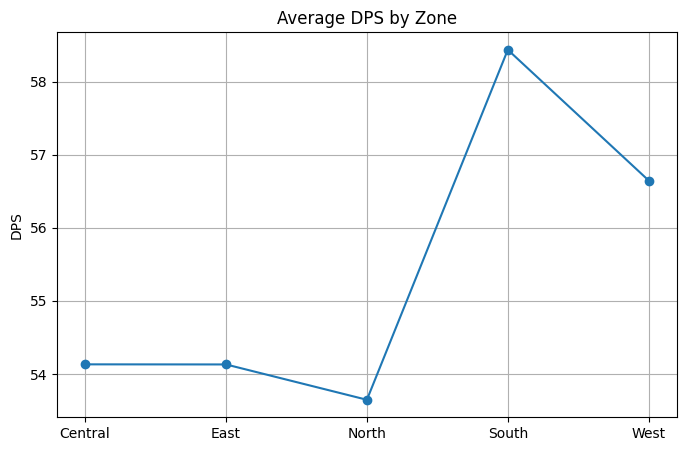

In [20]:
zone_avg = (
    df.groupby("Zone")["DPS"]
      .mean()
)

plt.figure(figsize=(8,5))

plt.plot(
    zone_avg.index,
    zone_avg.values,
    marker="o"
)

plt.title(
    "Average DPS by Zone"
)

plt.ylabel(
    "DPS"
)

plt.grid()

plt.show()

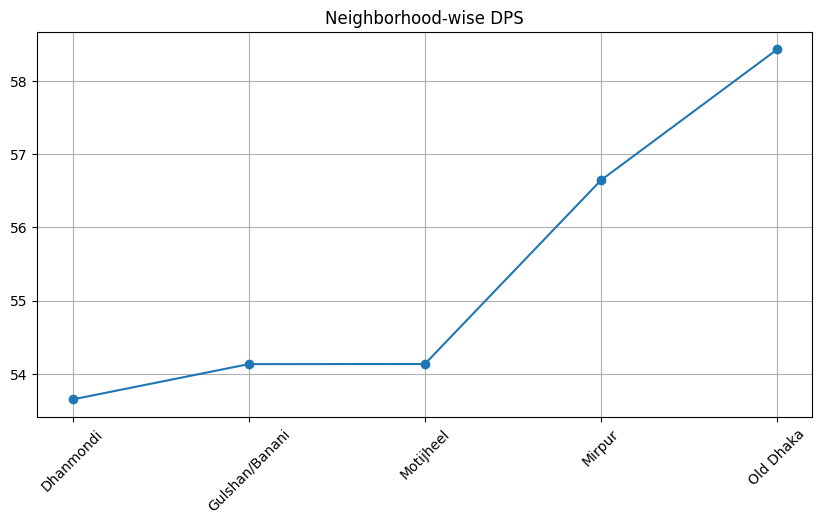

In [22]:
neigh_avg = (
    df.groupby("neighborhood")["DPS"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(10,5))

plt.plot(
    neigh_avg.index,
    neigh_avg.values,
    marker="o"
)

plt.xticks(rotation=45)

plt.title(
    "Neighborhood-wise DPS"
)

plt.grid()

plt.show()

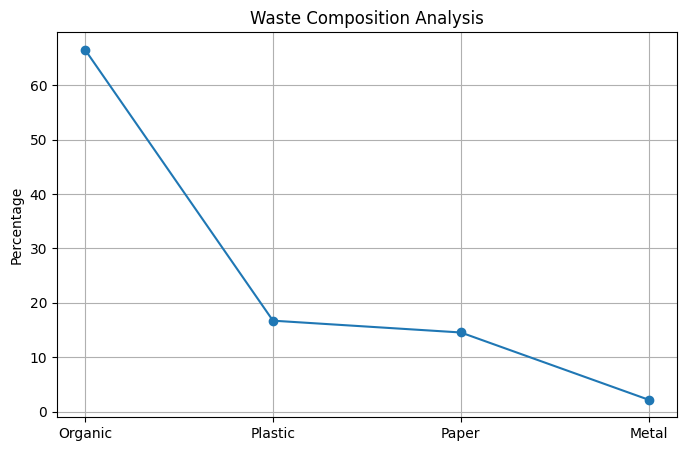

In [23]:
waste_avg = {
    "Organic":df["organic_pct"].mean(),
    "Plastic":df["plastic_pct"].mean(),
    "Paper":df["paper_pct"].mean(),
    "Metal":df["metal_pct"].mean()
}

plt.figure(figsize=(8,5))

plt.plot(
    list(waste_avg.keys()),
    list(waste_avg.values()),
    marker="o"
)

plt.title(
    "Waste Composition Analysis"
)

plt.ylabel(
    "Percentage"
)

plt.grid()

plt.show()

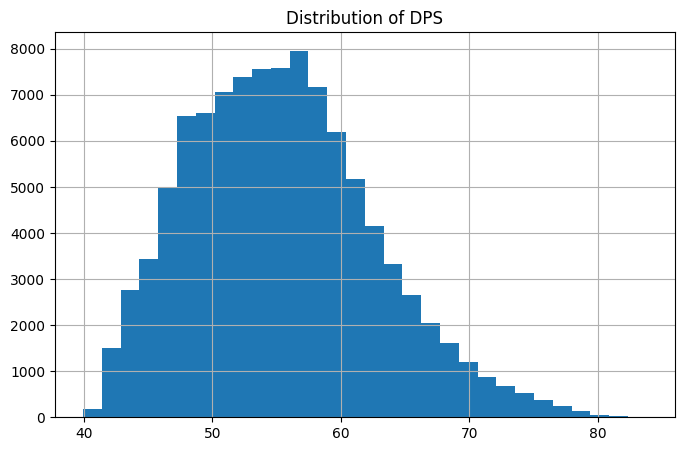

In [24]:
plt.figure(figsize=(8,5))

df["DPS"].hist(
    bins=30
)

plt.title(
    "Distribution of DPS"
)

plt.show()

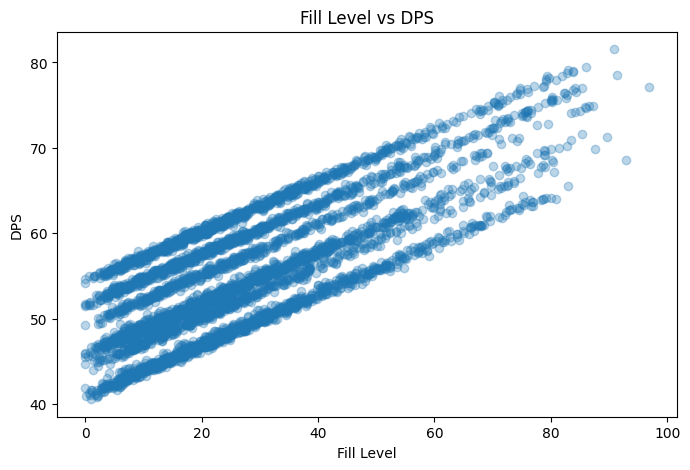

In [25]:
sample = df.sample(
    5000,
    random_state=42
)

plt.figure(figsize=(8,5))

plt.scatter(
    sample["fill_level"],
    sample["DPS"],
    alpha=0.3
)

plt.xlabel(
    "Fill Level"
)

plt.ylabel(
    "DPS"
)

plt.title(
    "Fill Level vs DPS"
)

plt.show()

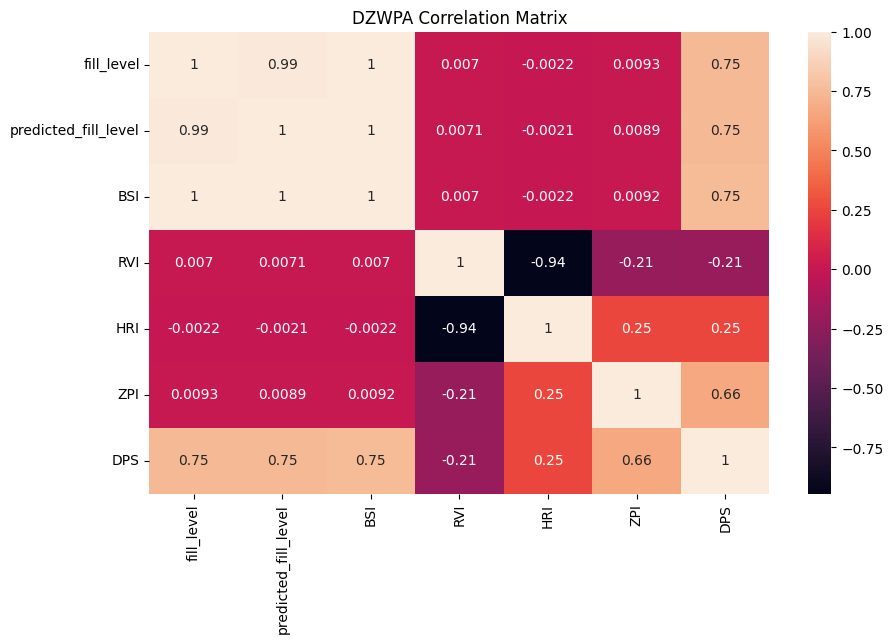

In [26]:
corr = df[
    [
        "fill_level",
        "predicted_fill_level",
        "BSI",
        "RVI",
        "HRI",
        "ZPI",
        "DPS"
    ]
].corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True
)

plt.title(
    "DZWPA Correlation Matrix"
)

plt.show()

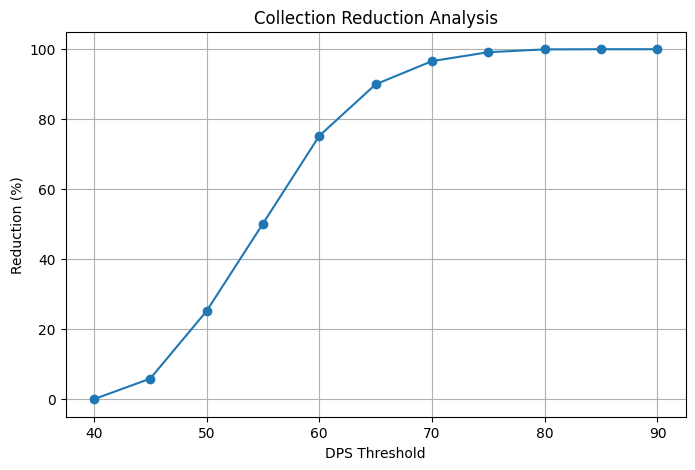

In [27]:
thresholds = range(
    40,
    91,
    5
)

reductions = []

for t in thresholds:

    smart = len(
        df[
            df["DPS"] >= t
        ]
    )

    reduction = (
        (len(df)-smart)
        /
        len(df)
    ) * 100

    reductions.append(
        reduction
    )

plt.figure(figsize=(8,5))

plt.plot(
    thresholds,
    reductions,
    marker="o"
)

plt.title(
    "Collection Reduction Analysis"
)

plt.xlabel(
    "DPS Threshold"
)

plt.ylabel(
    "Reduction (%)"
)

plt.grid()

plt.show()

In [28]:
top20 = (
    df.sort_values(
        "DPS",
        ascending=False
    )
    .head(20)
)

top20[
    [
        "bin_id",
        "Zone",
        "neighborhood",
        "DPS",
        "Priority"
    ]
]

,bin_id,Zone,neighborhood,DPS,Priority
99482,DHK-SL-04482,West,Mirpur,83.825650,Critical
95618,DHK-SL-00618,Central,Motijheel,83.213514,Critical
95558,DHK-SL-00558,South,Old Dhaka,83.149748,Critical
96502,DHK-SL-01502,West,Mirpur,82.950262,Critical
99250,DHK-SL-04250,West,Mirpur,82.748653,Critical
97821,DHK-SL-02821,South,Old Dhaka,82.529808,Critical
95370,DHK-SL-00370,Central,Motijheel,82.470646,Critical
95883,DHK-SL-00883,West,Mirpur,81.825281,Critical
92821,DHK-SL-02821,South,Old Dhaka,81.819945,Critical
99417,DHK-SL-04417,West,Mirpur,81.723955,Critical


In [29]:
zone_priority = pd.crosstab(
    df["Zone"],
    df["Priority"]
)

zone_priority

Priority,Critical,High,Low,Medium
Zone,,,,
Central,10,3760,1,15469
East,1,3618,0,16841
North,4,3442,0,16494
South,16,7289,0,12135
West,19,6590,0,14311


In [30]:
zone_summary.to_excel(
    "Zone_Summary.xlsx"
)

neighborhood_summary.to_excel(
    "Neighborhood_Summary.xlsx"
)

top20.to_excel(
    "Top20_Dispatch.xlsx",
    index=False
)

df.to_excel(
    "DZWPA_Results.xlsx",
    index=False
)

print(
    "All Results Exported Successfully"
)

All Results Exported Successfully


In [29]:
top20 = (
    df.sort_values(
        "DPS",
        ascending=False
    )
    .head(20)
)